In [4]:
import xarray as xr
import pandas as pd
import numpy as np

In [3]:
file_path = "/projects/prjs2023/chapter3/merged_base_MM_DM_fluxnet_GPP_with_FPCGPP.csv"

df_GPP = pd.read_csv(file_path)
df_GPP

,TIMESTAMP,GPP_NT_VUT_REF,source_file,date,GPP_fluxnet_monthly,site_id,lat,lon,time,GPP_base,GPP_droughtmort,GPP_monthlybackground,IGBP,GPP_base_weighted,GPP_MM_weighted,GPP_DM_weighted
0,200901,9.54930,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-01-01,296.02830,AR-SLu,-33.4648,-66.4598,2009-01-01,285.518830,262.471650,278.54617,MF,271.685398,255.468089,223.796802
1,200902,9.58507,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-02-01,268.38196,AR-SLu,-33.4648,-66.4598,2009-02-01,230.858140,229.888210,224.26028,MF,178.836003,164.984294,216.754947
2,200903,9.47598,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-03-01,293.75538,AR-SLu,-33.4648,-66.4598,2009-03-01,213.014100,237.345050,208.70354,MF,142.773372,136.638082,241.278467
3,200904,9.15312,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-04-01,274.59360,AR-SLu,-33.4648,-66.4598,2009-04-01,147.944170,187.903030,145.21759,MF,94.522959,87.378515,237.845408
4,200905,8.37331,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-05-01,259.57261,AR-SLu,-33.4648,-66.4598,2009-05-01,122.385124,139.978060,121.21308,MF,84.548539,78.978853,165.883574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16579,200908,1.22150,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-08-01,37.86650,ZM-Mon,-15.4391,23.2525,2009-08-01,0.000000,0.000000,0.00000,DBF,NaN,NaN,NaN
16580,200909,1.49847,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-09-01,44.95410,ZM-Mon,-15.4391,23.2525,2009-09-01,0.000000,0.000000,0.00000,DBF,NaN,NaN,NaN
16581,200910,1.57695,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-10-01,48.88545,ZM-Mon,-15.4391,23.2525,2009-10-01,0.000000,0.012477,0.00000,DBF,NaN,NaN,NaN
16582,200911,1.32243,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-11-01,39.67290,ZM-Mon,-15.4391,23.2525,2009-11-01,292.997680,288.632480,292.89285,DBF,NaN,NaN,NaN


In [9]:
file_path =  "/projects/prjs2023/chapter3/merged_base_DM_fluxnet_LE.csv"

df_LE = pd.read_csv(file_path)
df_LE

,TIMESTAMP,LE_F_MDS,source_file,date,LE_fluxnet_monthly,site_id,lat,lon,time,LE_base,LE_droughtmort
0,200901,51.4806,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-01-01,51.4806,AR-SLu,-33.4648,-66.4598,2009-01,73.462312,62.772611
1,200902,51.1634,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-02-01,51.1634,AR-SLu,-33.4648,-66.4598,2009-02,70.783836,59.862011
2,200903,51.4692,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-03-01,51.4692,AR-SLu,-33.4648,-66.4598,2009-03,55.616470,51.702378
3,200904,51.3780,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-04-01,51.3780,AR-SLu,-33.4648,-66.4598,2009-04,30.678778,32.966025
4,200905,51.4806,/projects/prjs2023/chapter3/fluxnet/FLX_AR-SLu...,2009-05-01,51.4806,AR-SLu,-33.4648,-66.4598,2009-05,18.741313,19.368477
...,...,...,...,...,...,...,...,...,...,...,...
16279,200908,16.0708,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-08-01,16.0708,ZM-Mon,-15.4391,23.2525,2009-08,11.747351,11.213865
16280,200909,16.0464,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-09-01,16.0464,ZM-Mon,-15.4391,23.2525,2009-09,10.969383,10.607138
16281,200910,16.0227,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-10-01,16.0227,ZM-Mon,-15.4391,23.2525,2009-10,18.487475,18.148342
16282,200911,16.0464,/projects/prjs2023/chapter3/fluxnet/FLX_ZM-Mon...,2009-11-01,16.0464,ZM-Mon,-15.4391,23.2525,2009-11,77.625667,78.567790


In [5]:
def kge_components(obs, sim):
    obs = np.array(obs)
    sim = np.array(sim)

    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]

    if len(obs) < 2:
        return None

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)

    kge = 1 - np.sqrt((r - 1)**2 +
                      (alpha - 1)**2 +
                      (beta - 1)**2)

    return r, alpha, beta, kge

In [6]:

# columns to compare against Fluxnet
model_cols = [
    "GPP_base_weighted",
    "GPP_MM_weighted",
    "GPP_DM_weighted"
]

results = []

for site, group in df_GPP.groupby("site_id"):

    obs = group["GPP_fluxnet_monthly"].values

    for model in model_cols:

        sim = group[model].values

        out = kge_components(obs, sim)

        if out is None:
            continue

        r, alpha, beta, kge = out

        results.append({
            "site_id": site,
            "model": model,
            "r": r,
            "alpha": alpha,
            "beta": beta,
            "KGE": kge
        })

kge_df_GPP = pd.DataFrame(results)

kge_df_GPP

,site_id,model,r,alpha,beta,KGE
0,AR-SLu,GPP_base_weighted,0.385679,1.192010,0.470754,0.166717
1,AR-SLu,GPP_MM_weighted,0.355604,1.357449,0.492501,0.105254
2,AR-SLu,GPP_DM_weighted,0.326048,1.282929,0.694787,0.207905
3,AR-Vir,GPP_base_weighted,0.521861,0.392984,0.806307,0.203381
4,AR-Vir,GPP_MM_weighted,0.562854,0.399029,0.821594,0.235741
...,...,...,...,...,...,...
388,US-Wi9,GPP_MM_weighted,0.813163,2.033722,1.794026,-0.316802
389,US-Wi9,GPP_DM_weighted,0.812343,2.009555,1.773743,-0.285727
390,US-Wkg,GPP_base_weighted,0.629732,0.591486,1.686984,0.119132
391,US-Wkg,GPP_MM_weighted,0.630151,0.599107,1.709266,0.105259


In [10]:
# columns to compare against Fluxnet
model_cols = [
    "LE_base",
    "LE_droughtmort"
]

results = []

for site, group in df_LE.groupby("site_id"):

    obs = group["LE_fluxnet_monthly"].values

    for model in model_cols:

        sim = group[model].values

        out = kge_components(obs, sim)

        if out is None:
            continue

        r, alpha, beta, kge = out

        results.append({
            "site_id": site,
            "model": model,
            "r": r,
            "alpha": alpha,
            "beta": beta,
            "KGE": kge
        })

kge_df_LE = pd.DataFrame(results)
kge_df_LE

,site_id,model,r,alpha,beta,KGE
0,AR-SLu,LE_base,0.197487,1.213951,0.900236,0.163487
1,AR-SLu,LE_droughtmort,0.208239,1.110235,0.843185,0.185366
2,AR-Vir,LE_base,0.409427,0.478514,0.551776,0.093563
3,AR-Vir,LE_droughtmort,0.413471,0.480766,0.551283,0.097245
4,AT-Neu,LE_base,0.957702,0.393145,0.539727,0.237168
...,...,...,...,...,...,...
385,US-Wi9,LE_droughtmort,0.799865,0.782799,0.622480,0.520676
386,US-Wkg,LE_base,0.840388,0.468099,1.064828,0.440896
387,US-Wkg,LE_droughtmort,0.832927,0.483792,1.072369,0.452623
388,ZM-Mon,LE_base,0.156282,1.109412,1.132373,0.138980


In [11]:
# =====================================================
# LE data
# =====================================================
site_meta_LE = (
    df_LE.groupby("site_id")
    .first()[["lon", "lat"]]
    .reset_index()
)

wide_LE = (
    kge_df_LE
    .pivot(index="site_id",
           columns="model",
           values="KGE")
)

df_LE_base = (
    wide_LE["LE_base"]
    .reset_index()
    .merge(site_meta_LE, on="site_id")
)

df_LE_dm = (
    wide_LE["LE_droughtmort"]
    .reset_index()
    .merge(site_meta_LE, on="site_id")
)

df_LE_scatter = (
    wide_LE.reset_index()
    .dropna()
)

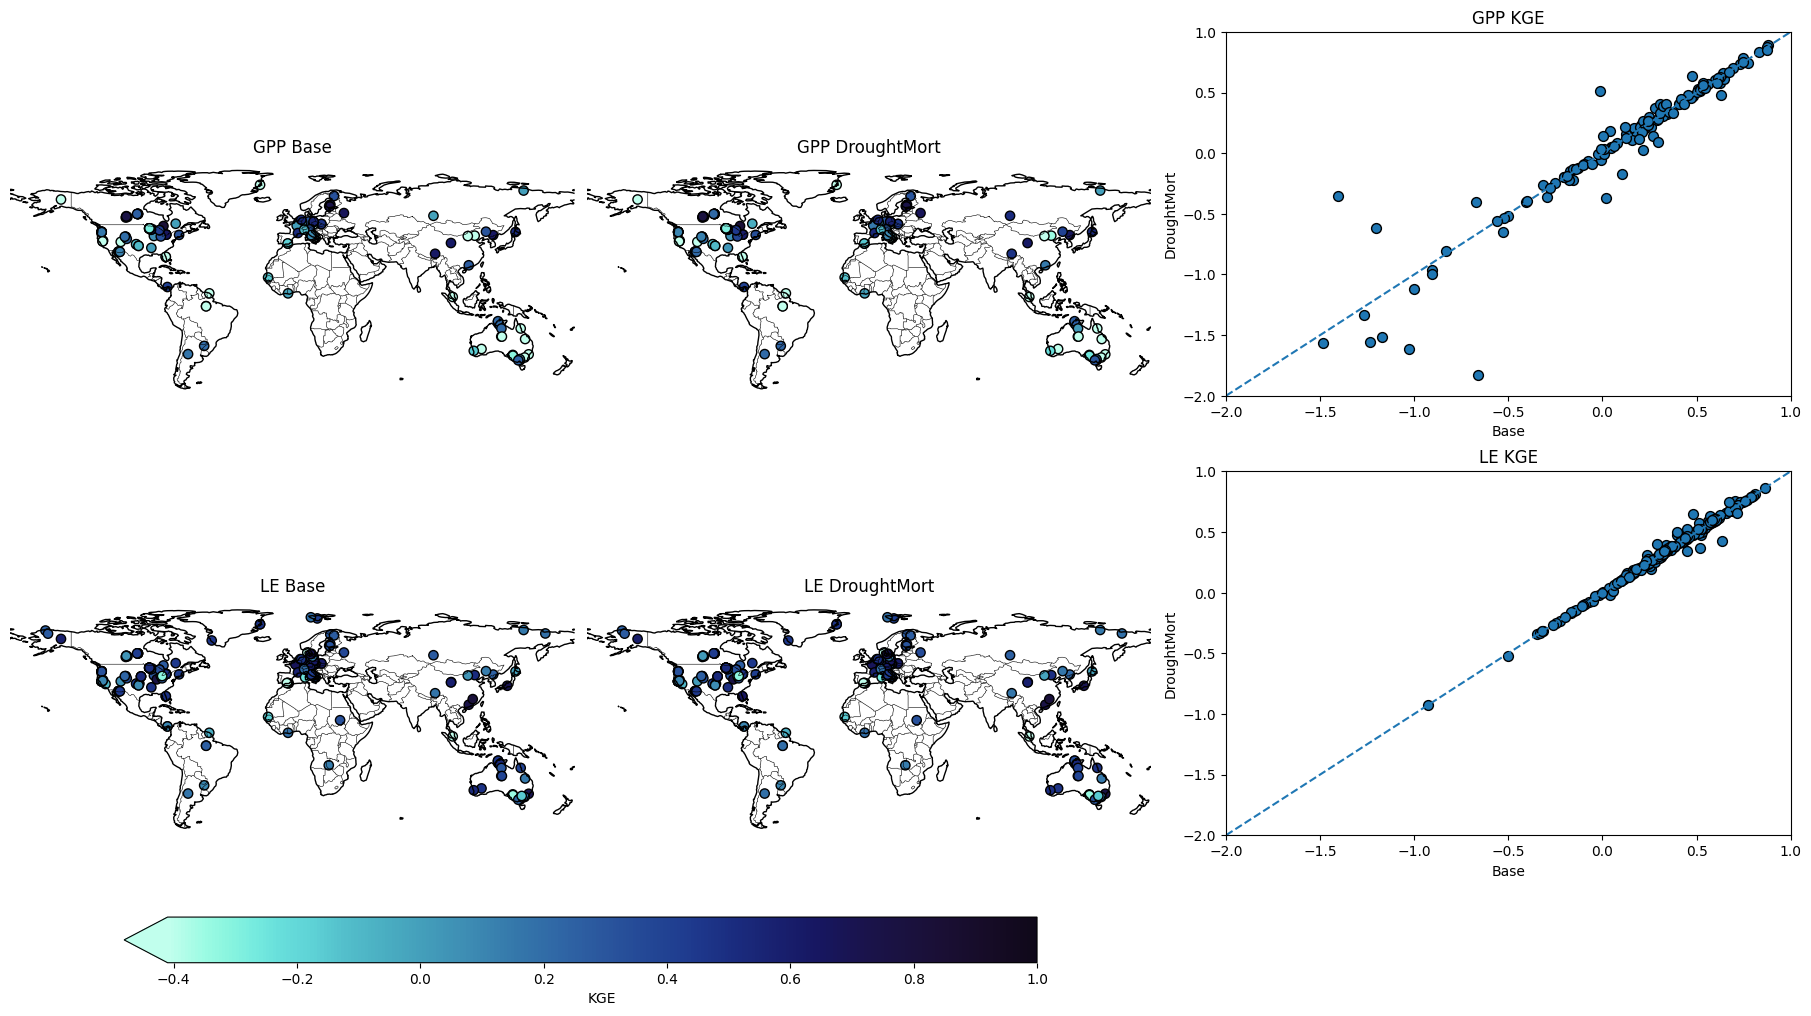

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(18,10), constrained_layout=True)

gs = fig.add_gridspec(
    2,
    3,
    width_ratios=[1,1,1]
)

# =====================================================
# GPP maps
# =====================================================
ax_gpp_base = fig.add_subplot(
    gs[0,0],
    projection=ccrs.PlateCarree()
)

ax_gpp_dm = fig.add_subplot(
    gs[0,1],
    projection=ccrs.PlateCarree()
)

# =====================================================
# LE maps
# =====================================================
ax_le_base = fig.add_subplot(
    gs[1,0],
    projection=ccrs.PlateCarree()
)

ax_le_dm = fig.add_subplot(
    gs[1,1],
    projection=ccrs.PlateCarree()
)

# =====================================================
# Scatter panels
# =====================================================
ax_gpp_scatter = fig.add_subplot(gs[0,2])
ax_le_scatter  = fig.add_subplot(gs[1,2])

# =====================================================
# GPP Base
# =====================================================
sc_gpp = ax_gpp_base.scatter(
    df_base["lon"],
    df_base["lat"],
    c=df_base["GPP_base_weighted"],
    cmap=cmaps.blue_bl111_r,
    vmin=-0.41,
    vmax=1,
    s=45,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax_gpp_base.coastlines()
ax_gpp_base.add_feature(cfeature.BORDERS, linewidth=0.4)
ax_gpp_base.set_extent([-180,180,-60,90])
ax_gpp_base.set_title("GPP Base")

# =====================================================
# GPP DM
# =====================================================
ax_gpp_dm.scatter(
    df_drought["lon"],
    df_drought["lat"],
    c=df_drought["GPP_DM_weighted"],
    cmap=cmaps.blue_bl111_r,
    vmin=-0.41,
    vmax=1,
    s=45,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax_gpp_dm.coastlines()
ax_gpp_dm.add_feature(cfeature.BORDERS, linewidth=0.4)
ax_gpp_dm.set_extent([-180,180,-60,90])
ax_gpp_dm.set_title("GPP DroughtMort")

# =====================================================
# LE Base
# =====================================================
sc_le = ax_le_base.scatter(
    df_LE_base["lon"],
    df_LE_base["lat"],
    c=df_LE_base["LE_base"],
    cmap=cmaps.blue_bl111_r,
    vmin=-0.41,
    vmax=1,
    s=45,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax_le_base.coastlines()
ax_le_base.add_feature(cfeature.BORDERS, linewidth=0.4)
ax_le_base.set_extent([-180,180,-60,90])
ax_le_base.set_title("LE Base")

# =====================================================
# LE DM
# =====================================================
ax_le_dm.scatter(
    df_LE_dm["lon"],
    df_LE_dm["lat"],
    c=df_LE_dm["LE_droughtmort"],
    cmap=cmaps.blue_bl111_r,
    vmin=-0.41,
    vmax=1,
    s=45,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax_le_dm.coastlines()
ax_le_dm.add_feature(cfeature.BORDERS, linewidth=0.4)
ax_le_dm.set_extent([-180,180,-60,90])
ax_le_dm.set_title("LE DroughtMort")

# =====================================================
# GPP scatter
# =====================================================
ax_gpp_scatter.scatter(
    df_scatter["GPP_base_weighted"],
    df_scatter["GPP_DM_weighted"],
    s=50,
    edgecolor="black"
)

ax_gpp_scatter.plot(
    [-2,1],
    [-2,1],
    "--"
)

ax_gpp_scatter.set_xlim([-2,1])
ax_gpp_scatter.set_ylim([-2,1])

ax_gpp_scatter.set_xlabel("Base")
ax_gpp_scatter.set_ylabel("DroughtMort")
ax_gpp_scatter.set_title("GPP KGE")

# =====================================================
# LE scatter
# =====================================================
ax_le_scatter.scatter(
    df_LE_scatter["LE_base"],
    df_LE_scatter["LE_droughtmort"],
    s=50,
    edgecolor="black"
)

ax_le_scatter.plot(
    [-2,1],
    [-2,1],
    "--"
)

ax_le_scatter.set_xlim([-2,1])
ax_le_scatter.set_ylim([-2,1])

ax_le_scatter.set_xlabel("Base")
ax_le_scatter.set_ylabel("DroughtMort")
ax_le_scatter.set_title("LE KGE")

# =====================================================
# Shared colorbar
# =====================================================
cbar = fig.colorbar(
    sc_gpp,
    ax=[
        ax_gpp_base,
        ax_gpp_dm,
        ax_le_base,
        ax_le_dm
    ],
    orientation="horizontal",
    shrink=0.8,
    pad=0.04,
    extend="min"
)

cbar.set_label("KGE")

for ax in [ax_gpp_base, ax_gpp_dm, ax_le_base, ax_le_dm]:
    ax.spines["geo"].set_visible(False)

plt.show()

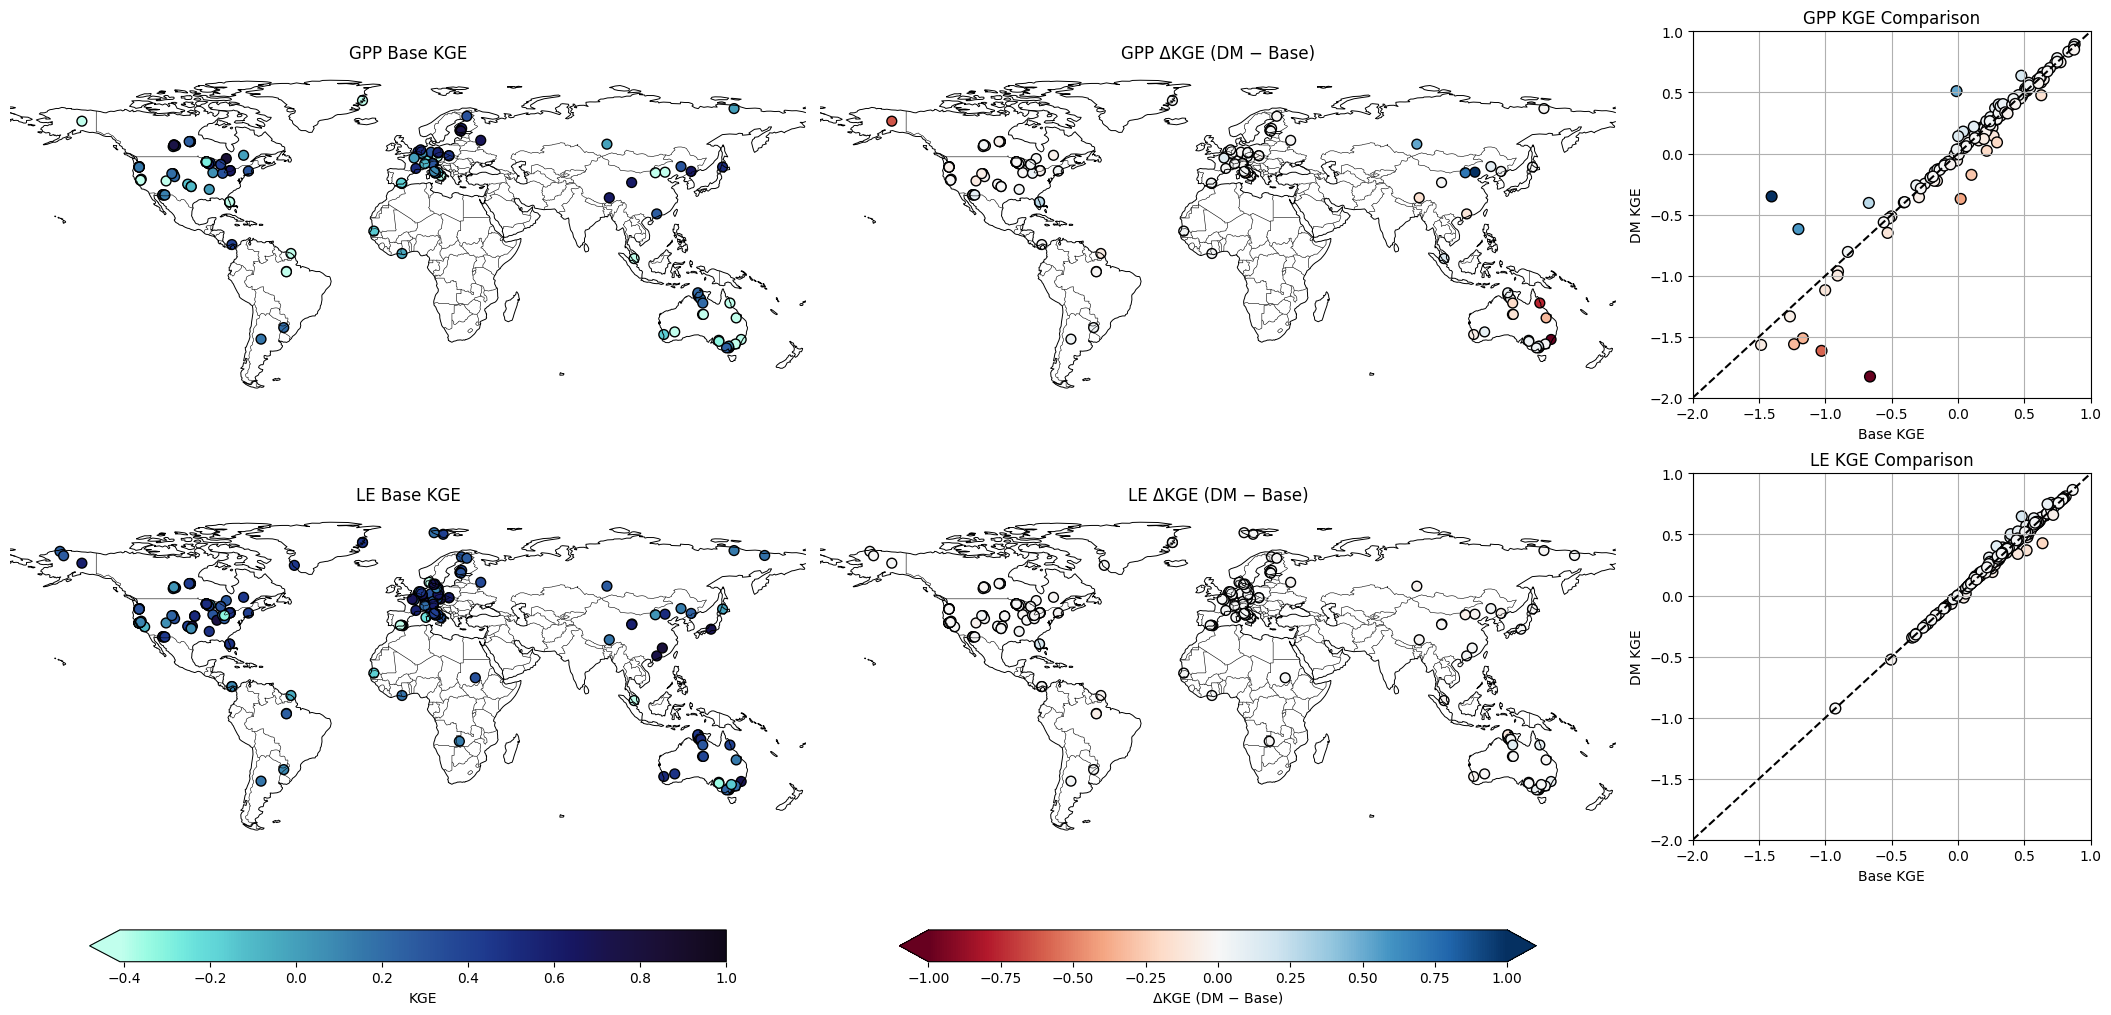

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import colormaps as cmaps

# =====================================================
# GPP data
# =====================================================
site_meta_GPP = (
    df_GPP.groupby("site_id")
    .first()[["lon", "lat"]]
    .reset_index()
)

wide_GPP = (
    kge_df_GPP
    .pivot(
        index="site_id",
        columns="model",
        values="KGE"
    )
)

df_GPP_base = (
    wide_GPP["GPP_base_weighted"]
    .reset_index()
    .merge(site_meta_GPP, on="site_id")
)

gpp_compare = (
    wide_GPP.reset_index()
    .dropna(subset=[
        "GPP_base_weighted",
        "GPP_DM_weighted"
    ])
)

gpp_compare["delta_kge"] = (
    gpp_compare["GPP_DM_weighted"]
    - gpp_compare["GPP_base_weighted"]
)

gpp_delta = (
    gpp_compare[["site_id", "delta_kge"]]
    .merge(site_meta_GPP, on="site_id")
)

# =====================================================
# LE data
# =====================================================
site_meta_LE = (
    df_LE.groupby("site_id")
    .first()[["lon", "lat"]]
    .reset_index()
)

wide_LE = (
    kge_df_LE
    .pivot(
        index="site_id",
        columns="model",
        values="KGE"
    )
)

df_LE_base = (
    wide_LE["LE_base"]
    .reset_index()
    .merge(site_meta_LE, on="site_id")
)

le_compare = (
    wide_LE.reset_index()
    .dropna(subset=[
        "LE_base",
        "LE_droughtmort"
    ])
)

le_compare["delta_kge"] = (
    le_compare["LE_droughtmort"]
    - le_compare["LE_base"]
)

le_delta = (
    le_compare[["site_id", "delta_kge"]]
    .merge(site_meta_LE, on="site_id")
)

# =====================================================
# Common color limits
# =====================================================
kge_min = -0.41

kge_max = 1

delta_max = 1

# =====================================================
# Figure layout
# =====================================================
fig = plt.figure(
    figsize=(21, 10),
    constrained_layout=True
)

gs = fig.add_gridspec(
    2,
    3,
    width_ratios=[1, 1, 0.5]
)

# =====================================================
# Axes
# =====================================================
ax1 = fig.add_subplot(
    gs[0, 0],
    projection=ccrs.PlateCarree()
)

ax2 = fig.add_subplot(
    gs[0, 1],
    projection=ccrs.PlateCarree()
)

ax3 = fig.add_subplot(gs[0, 2])

ax4 = fig.add_subplot(
    gs[1, 0],
    projection=ccrs.PlateCarree()
)

ax5 = fig.add_subplot(
    gs[1, 1],
    projection=ccrs.PlateCarree()
)

ax6 = fig.add_subplot(gs[1, 2])

# =====================================================
# GPP Base KGE
# =====================================================
sc_base_gpp = ax1.scatter(
    df_GPP_base["lon"],
    df_GPP_base["lat"],
    c=df_GPP_base["GPP_base_weighted"],
    cmap=cmaps.blue_bl111_r,
    vmin=kge_min,
    vmax=kge_max,
    s=50,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax1.coastlines(linewidth=0.7)
ax1.add_feature(cfeature.BORDERS, linewidth=0.4)

ax1.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

ax1.set_title("GPP Base KGE")

# =====================================================
# GPP ΔKGE
# =====================================================
sc_delta_gpp = ax2.scatter(
    gpp_delta["lon"],
    gpp_delta["lat"],
    c=gpp_delta["delta_kge"],
    cmap="RdBu",
    vmin=-delta_max,
    vmax=delta_max,
    s=50,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax2.coastlines(linewidth=0.7)
ax2.add_feature(cfeature.BORDERS, linewidth=0.4)

ax2.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

ax2.set_title("GPP ΔKGE (DM − Base)")

# =====================================================
# GPP Scatter
# =====================================================
ax3.scatter(
    gpp_compare["GPP_base_weighted"],
    gpp_compare["GPP_DM_weighted"],
    c=gpp_compare["delta_kge"],
    cmap="RdBu",
    vmin=-delta_max,
    vmax=delta_max,
    s=60,
    edgecolor="black"
)

ax3.plot(
    [-2, 1],
    [-2, 1],
    "--",
    color="black"
)

ax3.set_xlim([-2, 1])
ax3.set_ylim([-2, 1])

ax3.set_xlabel("Base KGE")
ax3.set_ylabel("DM KGE")

ax3.set_title("GPP KGE Comparison")
ax3.grid(True)

n_improved_gpp = np.sum(gpp_compare["delta_kge"] > 0)

# ax3.text(
#     0.03,
#     0.97,
#     f"{n_improved_gpp}/{len(gpp_compare)} improved",
#     transform=ax3.transAxes,
#     va="top"
# )

# =====================================================
# LE Base KGE
# =====================================================
sc_base_le = ax4.scatter(
    df_LE_base["lon"],
    df_LE_base["lat"],
    c=df_LE_base["LE_base"],
    cmap=cmaps.blue_bl111_r,
    vmin=kge_min,
    vmax=kge_max,
    s=50,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax4.coastlines(linewidth=0.7)
ax4.add_feature(cfeature.BORDERS, linewidth=0.4)

ax4.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

ax4.set_title("LE Base KGE")

# =====================================================
# LE ΔKGE
# =====================================================
sc_delta_le = ax5.scatter(
    le_delta["lon"],
    le_delta["lat"],
    c=le_delta["delta_kge"],
    cmap="RdBu",
    vmin=-delta_max,
    vmax=delta_max,
    s=50,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax5.coastlines(linewidth=0.7)
ax5.add_feature(cfeature.BORDERS, linewidth=0.4)

ax5.set_extent(
    [-180, 180, -60, 90],
    crs=ccrs.PlateCarree()
)

ax5.set_title("LE ΔKGE (DM − Base)")

# =====================================================
# LE Scatter
# =====================================================
ax6.scatter(
    le_compare["LE_base"],
    le_compare["LE_droughtmort"],
    c=le_compare["delta_kge"],
    cmap="RdBu",
    vmin=-delta_max,
    vmax=delta_max,
    s=60,
    edgecolor="black"
)

ax6.plot(
    [-2, 1],
    [-2, 1],
    "--",
    color="black"
)

ax6.set_xlim([-2, 1])
ax6.set_ylim([-2, 1])

ax6.set_xlabel("Base KGE")
ax6.set_ylabel("DM KGE")

ax6.set_title("LE KGE Comparison")
ax6.grid(True)

n_improved_le = np.sum(le_compare["delta_kge"] > 0)

# ax6.text(
#     0.03,
#     0.97,
#     f"{n_improved_le}/{len(le_compare)} improved",
#     transform=ax6.transAxes,
#     va="top"
# )

# =====================================================
# Remove map frame
# =====================================================
for ax in [ax1, ax2, ax4, ax5]:
    ax.spines["geo"].set_visible(False)

# =====================================================
# Colorbar for KGE
# =====================================================
cbar1 = fig.colorbar(
    sc_base_gpp,
    ax=[ax1, ax4],
    orientation="horizontal",
    shrink=0.8,
    pad=0.05,
    extend="min"
)

cbar1.set_label("KGE")

# =====================================================
# Colorbar for ΔKGE
# =====================================================
cbar2 = fig.colorbar(
    sc_delta_gpp,
    ax=[ax2, ax5],
    orientation="horizontal",
    shrink=0.8,
    pad=0.05, extend = 'both'
)

cbar2.set_label("ΔKGE (DM − Base)")

# =====================================================
# Save / show
# =====================================================
plt.savefig(
    "KGE_GPP_LE_DeltaComparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

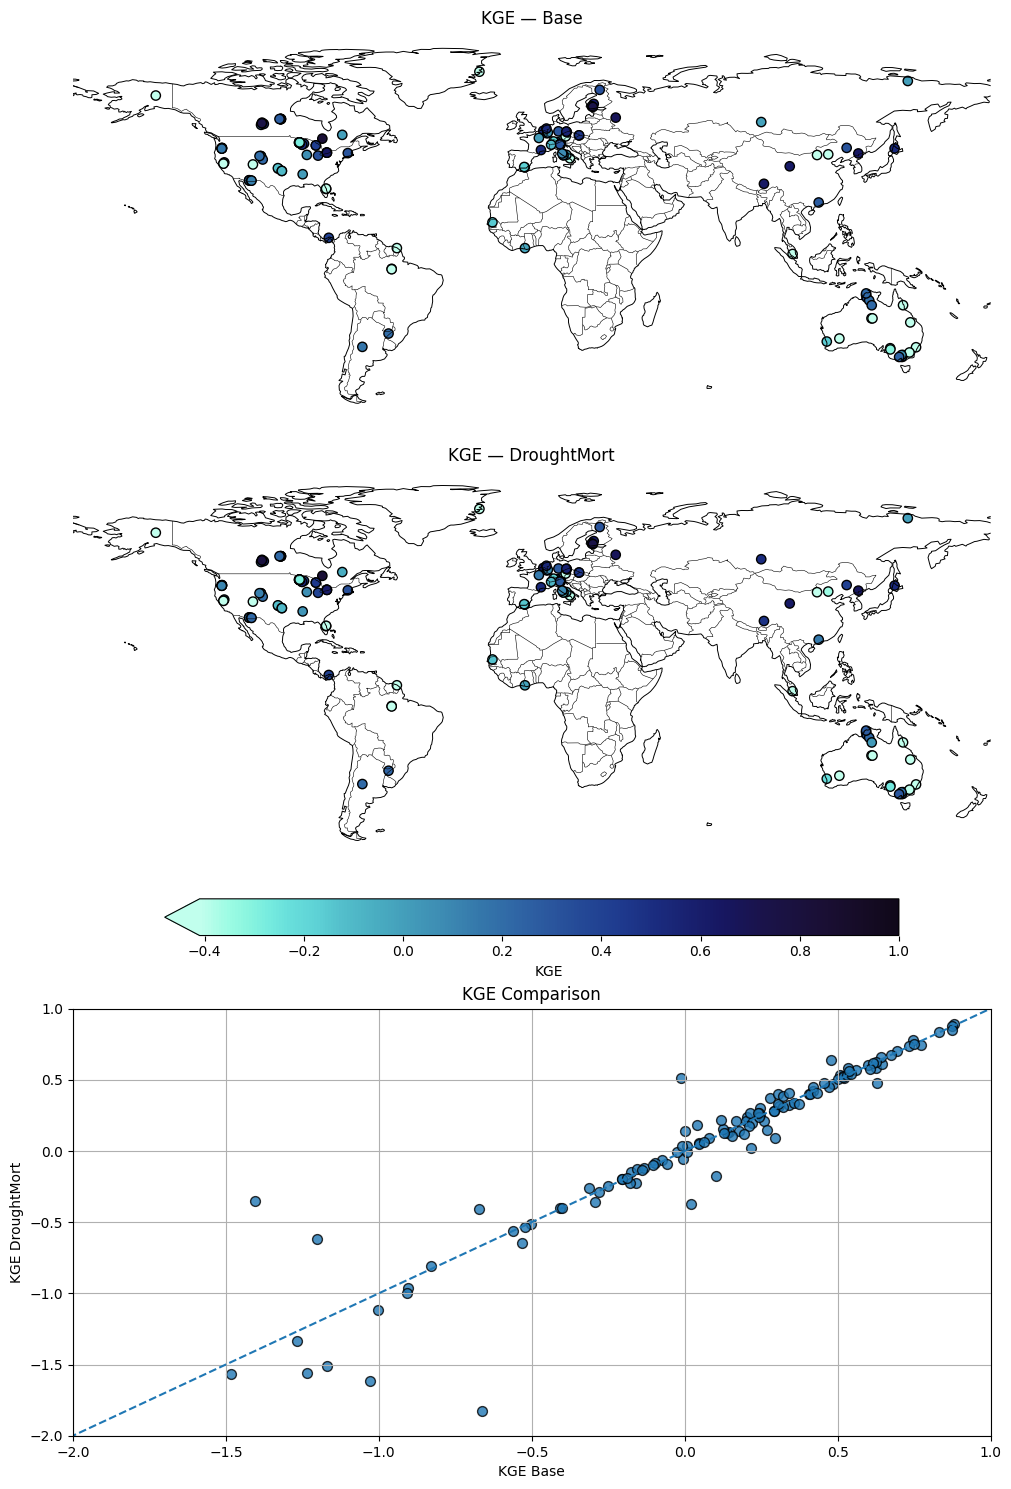

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import colormaps as cmaps

# -------------------------------------------------
# coordinates
# -------------------------------------------------
site_meta = (
    df_GPP.groupby("site_id")
    .first()[["lon", "lat"]]
    .reset_index()
)

# -------------------------------------------------
# subset models
# -------------------------------------------------
models = ["GPP_base_weighted", "GPP_DM_weighted"]

kge_sub = kge_df_GPP[
    kge_df_GPP["model"].isin(models)
][["site_id", "model", "KGE"]].copy()

kge_sub = kge_sub.dropna(subset=["KGE"])

# -------------------------------------------------
# wide format
# -------------------------------------------------
wide = kge_sub.pivot(
    index="site_id",
    columns="model",
    values="KGE"
)

# -------------------------------------------------
# merge coordinates
# -------------------------------------------------
df_base = (
    wide["GPP_base_weighted"]
    .reset_index()
    .merge(site_meta, on="site_id")
)

df_drought = (
    wide["GPP_DM_weighted"]
    .reset_index()
    .merge(site_meta, on="site_id")
)

# combined dataframe for scatter
df_scatter = (
    wide.reset_index()
    .dropna()
)

# -------------------------------------------------
# map extent
# -------------------------------------------------
lon_min = df_GPP["lon"].min()
lon_max = df_GPP["lon"].max()
lat_min = df_GPP["lat"].min()
lat_max = df_GPP["lat"].max()

# -------------------------------------------------
# figure layout
# -------------------------------------------------
fig = plt.figure(figsize=(10, 15), constrained_layout=True)

gs = fig.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=[1, 1, 1]
)

# -------------------------------------------------
# TOP: Base map
# -------------------------------------------------
ax0 = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())

sc0 = ax0.scatter(
    df_base["lon"],
    df_base["lat"],
    c=df_base["GPP_base_weighted"],
    cmap=cmaps.blue_bl111_r,
    vmin=-0.41,
    vmax=1,
    s=45,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax0.coastlines(linewidth=0.7)
ax0.add_feature(cfeature.BORDERS, linewidth=0.4)

ax0.set_extent(
    [-180, 180, 90, -60],
    crs=ccrs.PlateCarree()
)

ax0.set_title("KGE — Base")

# -------------------------------------------------
# MIDDLE: Drought map
# -------------------------------------------------
ax1 = fig.add_subplot(gs[1], projection=ccrs.PlateCarree())

sc1 = ax1.scatter(
    df_drought["lon"],
    df_drought["lat"],
    c=df_drought["GPP_DM_weighted"],
    cmap=cmaps.blue_bl111_r,
    vmin=-0.41,
    vmax=1,
    s=45,
    edgecolor="black",
    transform=ccrs.PlateCarree()
)

ax1.coastlines(linewidth=0.7)
ax1.add_feature(cfeature.BORDERS, linewidth=0.4)

ax1.set_extent(
    [-180, 180, 90, -60],
    crs=ccrs.PlateCarree()
)

ax1.set_title("KGE — DroughtMort")

# shared colorbar
cbar = fig.colorbar(
    sc1,
    ax=[ax0, ax1],
    orientation="horizontal",
    shrink=0.8,
    pad=0.05, extend = "min"
)

cbar.set_label("KGE")

# -------------------------------------------------
# BOTTOM: Scatter comparison
# -------------------------------------------------
ax2 = fig.add_subplot(gs[2])

ax2.scatter(
    df_scatter["GPP_base_weighted"],
    df_scatter["GPP_DM_weighted"],
    s=50,
    edgecolor="black",
    alpha=0.8
)

# 1:1 line
lims = [
    min(ax2.get_xlim()[0], ax2.get_ylim()[0]),
    max(ax2.get_xlim()[1], ax2.get_ylim()[1]),
]

ax2.plot(
    lims,
    lims,
    linestyle="--"
)

ax2.set_xlim([-2,1])
ax2.set_ylim([-2,1])

ax2.set_xlabel("KGE Base")
ax2.set_ylabel("KGE DroughtMort")

ax2.set_title("KGE Comparison")

ax2.grid(True)

ax0.spines['geo'].set_visible(False)
ax1.spines['geo'].set_visible(False)

# plt.savefig("kge_comparison.png", dpi=300)
plt.show()